Running simulations...

[Oscillator]

No sponge:
Period = 414.8 min
        = 13.83 generations

Sponge:
Period = 406.5 min
        = 13.55 generations

Period change: -2.00 %

[TetR]

TetR total: 7.9 - 877.1
TetR free: 1.9 - 837.1

[Sponge]

Sponge parameters:
S_phys = 80
eta = 0.5
S_eff = 40.0
Kd = 6
n_s = 1.5

Average buffering: 38.2%
Maximum buffering: 77.9%

[PLtetO1]

Activity range: 0.050 - 0.914
Duty cycle: 25.1 %

[C31]

mRNA: 7.2 - 131.7
Protein: 170 - 2404
Peak concentration: 3.99 μM

[Phase lag]
TetR_free_to_PLtetO: 230.0 min
PLtetO_to_C31_mRNA: 3.0 min
C31_mRNA_to_C31: 26.0 min
TetR_free_to_C31: 259.0 min


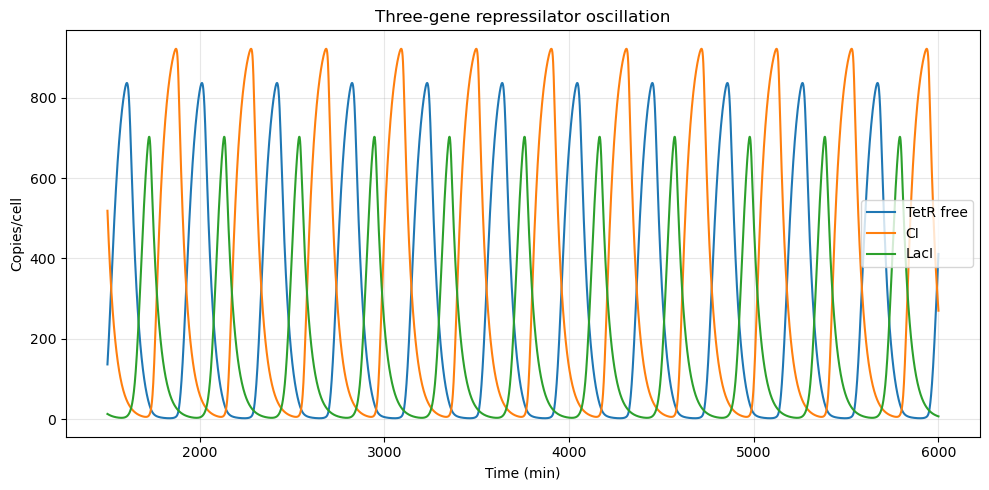

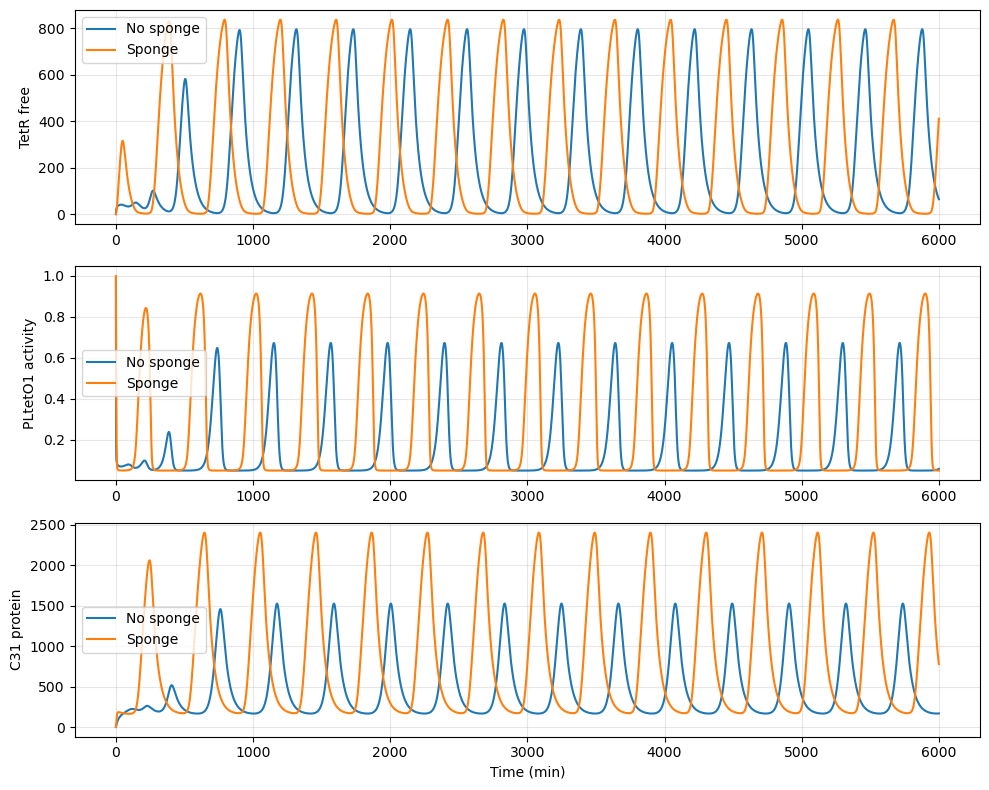

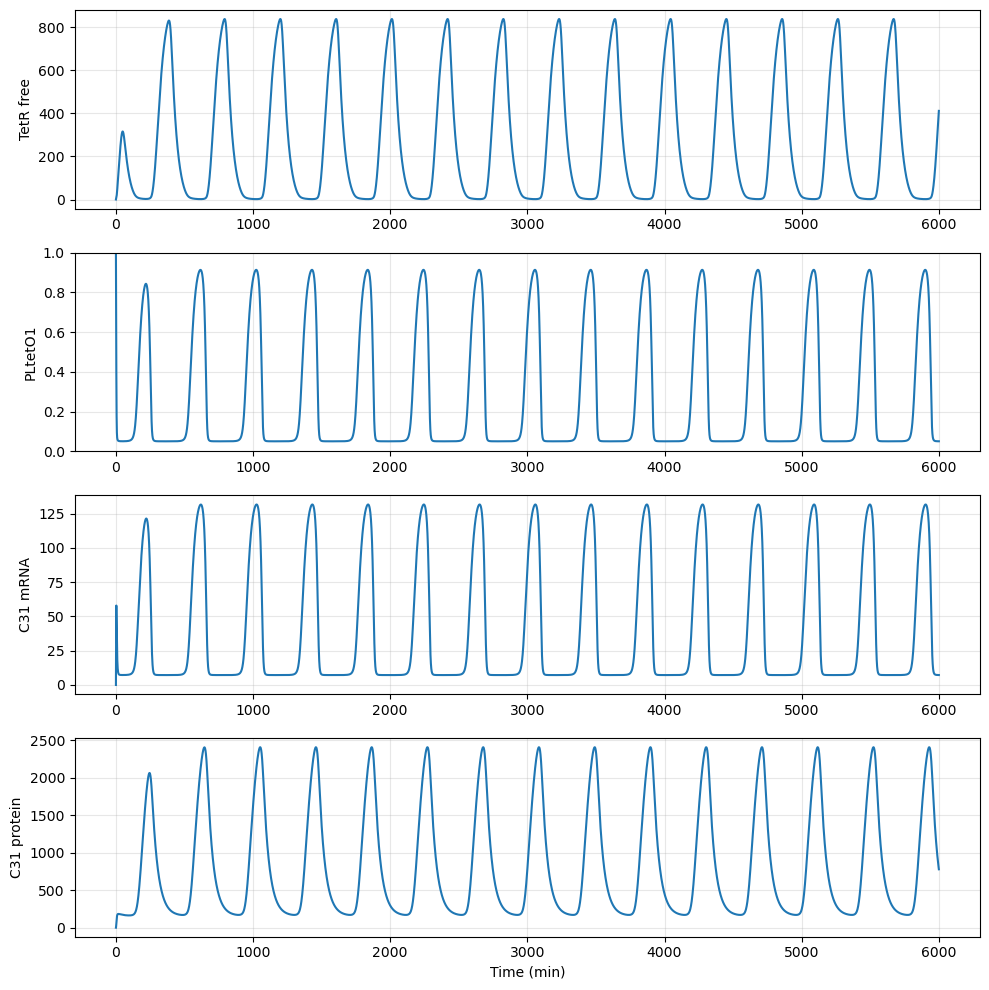

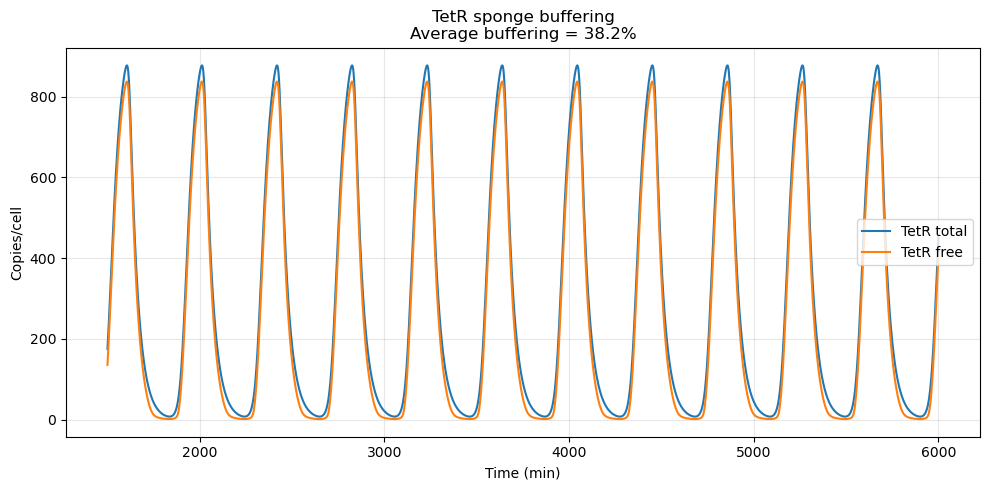


Generated files:
----------------
Fig1_three_gene.png
Fig2_sponge_vs_no_sponge.png
Fig3_TetR_PLtetO_C31_cascade.png
Fig4_TetR_total_vs_free.png
v36_final_simulation.csv

Current directory: e:\Vscodeprojects\建模作业\作业三\week3A


In [9]:
import math
import numpy as np
import os
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# =====================================================
# Path
# =====================================================
OUT = lambda f: os.path.join(os.getcwd(), f)

# =====================================================
# Parameters
# =====================================================
class P:
    # Repressilator
    lambd = 1000
    K = 13
    n = 3
    Td = 30
    gamma = math.log(2) / Td

    # TetR sponge
    S_phys = 80          # 40 plasmids * 2 tetO per plasmid
    eta = 0.5            # effective accessibility
    S_eff = S_phys * eta
    Kd = 6               # TetR-tetO binding parameter
    n_s = 1.5            # cooperativity (Potvin-Trottier 2016 SI 4.3.1)

    # PLtetO1
    K_R = 6
    n_R = 2
    H_leak = 0.05

    # C31 output module
    N_C = 10
    k_tx = 5
    gamma_m = math.log(2) / 2
    beta = 0.5
    mu = math.log(2) / 30      # protein loss by dilution
    copies_per_uM = 602

# =====================================================
# Regulatory functions
# =====================================================
def hill_rep(x):
    """Hill repression: H(x)=K^n/(K^n+x^n)"""
    return (P.K ** P.n) / (P.K ** P.n + x ** P.n + 1e-12)

def PLtetO(Tf):
    """PLtetO1 promoter activity: High TetR_free -> repression; Low -> activation"""
    return P.H_leak + (1 - P.H_leak) / (1 + (Tf / P.K_R) ** P.n_R)

# =====================================================
# TetR sponge equilibrium
# =====================================================
def free_TetR(Ttot, S):
    """
    TetR sponge binding equilibrium:
    T_total = T_free + T_bound
    T_bound = S_eff * T_free^ns / (T_free^ns + Kd^ns)
    ns describes TetR-tetO cooperative binding.
    S is additional sponge capacity, not repressilator tetO sites.
    """
    if Ttot <= 0:
        return 0
    low, high = 0, Ttot
    for _ in range(100):
        Tf = (low + high) / 2
        bound = S * (Tf ** P.n_s) / (Tf ** P.n_s + P.Kd ** P.n_s)
        total = Tf + bound
        if total > Ttot:
            high = Tf
        else:
            low = Tf
    return (low + high) / 2

# =====================================================
# ODE model
# =====================================================
def make_model(S):
    def ode(t, y):
        TetR, CI, LacI, mRNA, C31 = y
        Tf = free_TetR(TetR, S)   # TetR total -> free

        # Repressilator
        dTetR = P.gamma * (P.lambd * hill_rep(LacI) - TetR)
        dCI = P.gamma * (P.lambd * hill_rep(Tf) - CI)
        dLacI = P.gamma * (P.lambd * hill_rep(CI) - LacI)

        # PLtetO1 promoter
        promoter = PLtetO(Tf)

        # C31 mRNA
        dmRNA = P.N_C * P.k_tx * promoter - P.gamma_m * mRNA

        # C31 protein (loss mainly by dilution)
        dC31 = P.beta * mRNA - P.mu * C31

        return [dTetR, dCI, dLacI, dmRNA, dC31]
    return ode

# =====================================================
# Simulation
# =====================================================
t_eval = np.linspace(0, 6000, 6000)
y0 = [0.5, 0.2, 1, 0, 0]

print("Running simulations...")
sol_no = solve_ivp(make_model(0), (0, 6000), y0, t_eval=t_eval,
                   method="BDF", rtol=1e-6, atol=1e-8)
sol_sp = solve_ivp(make_model(P.S_eff), (0, 6000), y0, t_eval=t_eval,
                   method="BDF", rtol=1e-6, atol=1e-8)
t = sol_no.t

# =====================================================
# Period analysis
# =====================================================
def calc_period(signal):
    steady = signal[1500:]
    peaks, _ = find_peaks(steady, distance=100, prominence=np.ptp(steady) * 0.1)
    peaks = peaks + 1500
    if len(peaks) >= 2:
        return np.mean(np.diff(t[peaks]))
    return np.nan

period_no = calc_period(sol_no.y[1])
period_sp = calc_period(sol_sp.y[1])

# =====================================================
# Extract variables
# =====================================================
TetR_no = sol_no.y[0]
TetR_sp = sol_sp.y[0]
Tf_no = np.array([free_TetR(x, 0) for x in TetR_no])
Tf_sp = np.array([free_TetR(x, P.S_eff) for x in TetR_sp])
PL_no = np.array([PLtetO(x) for x in Tf_no])
PL_sp = np.array([PLtetO(x) for x in Tf_sp])
C31_no = sol_no.y[4]
C31_sp = sol_sp.y[4]
mask = t > 1500

# =====================================================
# Sponge buffering analysis
# =====================================================
buffering = (TetR_sp - Tf_sp) / np.maximum(TetR_sp, 1)
average_buffering = np.mean(buffering[mask])
maximum_buffering = np.max(buffering[mask])

# =====================================================
# Phase lag analysis
# =====================================================
def peak_time(signal):
    peaks, _ = find_peaks(signal[1500:], prominence=np.ptp(signal) * 0.1)
    if len(peaks) == 0:
        return np.nan
    return t[peaks[0] + 1500]

lags = {}
lags["TetR_free_to_PLtetO"] = peak_time(PL_sp) - peak_time(Tf_sp)
lags["PLtetO_to_C31_mRNA"] = peak_time(sol_sp.y[3]) - peak_time(PL_sp)
lags["C31_mRNA_to_C31"] = peak_time(C31_sp) - peak_time(sol_sp.y[3])
lags["TetR_free_to_C31"] = peak_time(C31_sp) - peak_time(Tf_sp)

# =====================================================
# FINAL MODEL SUMMARY
# =====================================================

print("\n[Oscillator]")
print(f"""
No sponge:
Period = {period_no:.1f} min
        = {period_no/30:.2f} generations

Sponge:
Period = {period_sp:.1f} min
        = {period_sp/30:.2f} generations

Period change: {(period_sp-period_no)/period_no*100:.2f} %
""")

print("[TetR]")
print(f"""
TetR total: {TetR_sp[mask].min():.1f} - {TetR_sp[mask].max():.1f}
TetR free: {Tf_sp[mask].min():.1f} - {Tf_sp[mask].max():.1f}
""")

print("[Sponge]")
print(f"""
Sponge parameters:
S_phys = {P.S_phys}
eta = {P.eta}
S_eff = {P.S_eff}
Kd = {P.Kd}
n_s = {P.n_s}

Average buffering: {average_buffering*100:.1f}%
Maximum buffering: {maximum_buffering*100:.1f}%
""")

print("[PLtetO1]")
print(f"""
Activity range: {PL_sp[mask].min():.3f} - {PL_sp[mask].max():.3f}
Duty cycle: {np.mean(PL_sp[mask]>0.5)*100:.1f} %
""")

print("[C31]")
print(f"""
mRNA: {sol_sp.y[3][mask].min():.1f} - {sol_sp.y[3][mask].max():.1f}
Protein: {C31_sp[mask].min():.0f} - {C31_sp[mask].max():.0f}
Peak concentration: {np.max(C31_sp[mask])/P.copies_per_uM:.2f} μM
""")

print("[Phase lag]")
for k, v in lags.items():
    print(f"{k}: {v:.1f} min")
print("=" * 70)

# =====================================================
# Figure 1: Three gene repressilator
# =====================================================
plt.figure(figsize=(10,5))
plt.plot(t[mask], Tf_sp[mask], label="TetR free")
plt.plot(t[mask], sol_sp.y[1][mask], label="CI")
plt.plot(t[mask], sol_sp.y[2][mask], label="LacI")
plt.title("Three-gene repressilator oscillation")
plt.xlabel("Time (min)")
plt.ylabel("Copies/cell")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT("Fig1_three_gene.png"), dpi=300)
plt.show()

# =====================================================
# Figure 2: Sponge vs no sponge
# =====================================================
plt.figure(figsize=(10,8))
plt.subplot(3,1,1)
plt.plot(t, Tf_no, label="No sponge")
plt.plot(t, Tf_sp, label="Sponge")
plt.ylabel("TetR free")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(3,1,2)
plt.plot(t, PL_no, label="No sponge")
plt.plot(t, PL_sp, label="Sponge")
plt.ylabel("PLtetO1 activity")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(3,1,3)
plt.plot(t, C31_no, label="No sponge")
plt.plot(t, C31_sp, label="Sponge")
plt.ylabel("C31 protein")
plt.xlabel("Time (min)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT("Fig2_sponge_vs_no_sponge.png"), dpi=300)
plt.show()



# =====================================================
# Figure 3: Full TetR-PLtetO1-C31 cascade
# =====================================================
plt.figure(figsize=(10,10))
plt.subplot(4,1,1)
plt.plot(t, Tf_sp, label="TetR free")
plt.ylabel("TetR free")
plt.grid(alpha=0.3)

plt.subplot(4,1,2)
plt.plot(t, PL_sp, label="PLtetO1 activity")
plt.ylabel("PLtetO1")
plt.ylim(0,1)
plt.grid(alpha=0.3)

plt.subplot(4,1,3)
plt.plot(t, sol_sp.y[3], label="C31 mRNA")
plt.ylabel("C31 mRNA")
plt.grid(alpha=0.3)

plt.subplot(4,1,4)
plt.plot(t, C31_sp, label="C31 protein")
plt.ylabel("C31 protein")
plt.xlabel("Time (min)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT("Fig3_TetR_PLtetO_C31_full_cascade.png"), dpi=300)
plt.show()
# =====================================================
# Figure 4: TetR total vs free
# =====================================================
plt.figure(figsize=(10,5))
plt.plot(t[mask], TetR_sp[mask], label="TetR total")
plt.plot(t[mask], Tf_sp[mask], label="TetR free")
plt.xlabel("Time (min)")
plt.ylabel("Copies/cell")
plt.title(f"TetR sponge buffering\nAverage buffering = {average_buffering*100:.1f}%")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT("Fig4_TetR_total_vs_free.png"), dpi=300)
plt.show()

# =====================================================
# Save simulation data
# =====================================================
np.savetxt(
    OUT("v36_final_simulation.csv"),
    np.column_stack([t, TetR_sp, Tf_sp, sol_sp.y[1], sol_sp.y[2],
                     PL_sp, sol_sp.y[3], C31_sp, buffering]),
    delimiter=",",
    header="time_min,TetR_total,TetR_free,CI,LacI,PLtetO1_activity,C31_mRNA,C31_protein,sponge_buffering",
    comments=""
)

print("\nGenerated files:")
print("----------------")
print("Fig1_three_gene.png")
print("Fig2_sponge_vs_no_sponge.png")
print("Fig3_TetR_PLtetO_C31_cascade.png")
print("Fig4_TetR_total_vs_free.png")
print("v36_final_simulation.csv")
print("\nCurrent directory:", os.getcwd())